<a href="https://colab.research.google.com/github/shreyansh-sinha14/brain-tumor-detection/blob/main/DL_Brain_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 0 - Setup environment

!pip install -q tqdm

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models, utils

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
!unzip -q archive.zip -d /content/brain_tumor_dataset || true


In [ ]:
!ls -la /content/brain_tumor_dataset
!ls -la /content/brain_tumor_dataset/yes | head -n 5
!ls -la /content/brain_tumor_dataset/no  | head -n 5


total 20
drwxr-xr-x 5 root root 4096 Nov  5 13:19 .
drwxr-xr-x 1 root root 4096 Nov  5 13:19 ..
drwxr-xr-x 4 root root 4096 Nov  5 13:19 brain_tumor_dataset
drwxr-xr-x 2 root root 4096 Nov  5 13:19 no
drwxr-xr-x 2 root root 4096 Nov  5 13:19 yes
total 5208
drwxr-xr-x 2 root root   4096 Nov  5 13:19 .
drwxr-xr-x 5 root root   4096 Nov  5 13:19 ..
-rw-r--r-- 1 root root  20782 Oct 21  2019 Y100.JPG
-rw-r--r-- 1 root root  55036 Oct 21  2019 Y101.jpg
total 3796
drwxr-xr-x 2 root root   4096 Nov  5 13:19 .
drwxr-xr-x 5 root root   4096 Nov  5 13:19 ..
-rw-r--r-- 1 root root   3848 Oct 21  2019 10 no.jpg
-rw-r--r-- 1 root root   3475 Oct 21  2019 11 no.jpg


In [ ]:

data_dir = "/content/brain_tumor_dataset/brain_tumor_dataset"


from torchvision import datasets, transforms

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=base_transform)
print("✅ Corrected Classes:", full_dataset.classes)
print("✅ Total images:", len(full_dataset))


✅ Corrected Classes: ['no', 'yes']
✅ Total images: 253


In [ ]:
# Data Transforms and DataLoaders

from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import torch

# Use ImageNet normalization (ResNet18 expects it)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Data augmentations for training (helps model generalize)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Validation/test: just resize and normalize (no random augmentations)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


class SubsetImageFolder(Subset):
    def __init__(self, imagefolder, indices, transform=None):
        super().__init__(imagefolder, indices)
        self.imagefolder = imagefolder
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        path, target = self.imagefolder.samples[real_idx]
        img = self.imagefolder.loader(path)
        if self.transform:
            img = self.transform(img)
        return img, target

# subsets with correct transforms
train_dataset = SubsetImageFolder(full_dataset, train_idx, transform=train_transform)
val_dataset   = SubsetImageFolder(full_dataset, val_idx, transform=val_transform)
test_dataset  = SubsetImageFolder(full_dataset, test_idx, transform=val_transform)

# DataLoaders
batch_size = 8  # small batch since dataset is small
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("✅ DataLoaders created successfully!")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


✅ DataLoaders created successfully!
Train batches: 45, Val batches: 10, Test batches: 10


In [ ]:
# Define Model (Transfer Learning with ResNet18)

import torch.nn as nn
from torchvision import models


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)


model = models.resnet18(pretrained=True)


for param in model.parameters():
    param.requires_grad = False


num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)  # 2 output classes: no / yes


model = model.to(device)

print("✅ Model ready for training!")
print(model)


✅ Using device: cpu


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s]


✅ Model ready for training!
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (

In [ ]:

from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms

data_dir = "/content/brain_tumor_dataset/brain_tumor_dataset"

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=base_transform)
class_names = full_dataset.classes
print("✅ Corrected Classes:", class_names)
print("✅ Total images:", len(full_dataset))


targets = [s[1] for s in full_dataset.samples]
indices = list(range(len(full_dataset)))

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices, targets, test_size=0.30, stratify=targets, random_state=42
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"✅ Train size: {len(train_idx)}, Val size: {len(val_idx)}, Test size: {len(test_idx)}")


✅ Corrected Classes: ['no', 'yes']
✅ Total images: 253
✅ Train size: 177, Val size: 38, Test size: 38


In [ ]:
# ✅ REBUILD DATASETS AND DATALOADERS after fixing path/splits
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

class SubsetImageFolder(Subset):
    def __init__(self, imagefolder, indices, transform=None):
        super().__init__(imagefolder, indices)
        self.imagefolder = imagefolder
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        path, target = self.imagefolder.samples[real_idx]
        img = self.imagefolder.loader(path)
        if self.transform:
            img = self.transform(img)
        return img, target

# Build datasets
train_dataset = SubsetImageFolder(full_dataset, train_idx, transform=train_transform)
val_dataset   = SubsetImageFolder(full_dataset, val_idx, transform=val_transform)
test_dataset  = SubsetImageFolder(full_dataset, test_idx, transform=val_transform)

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("✅ Datasets rebuilt successfully!")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


✅ Datasets rebuilt successfully!
Train: 177, Val: 38, Test: 38


In [ ]:
# Training & Validation Loop
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

num_epochs = 10
best_val_loss = float('inf')
train_history, val_history = [], []

for epoch in range(num_epochs):
    print(f"\n🔹 Epoch {epoch+1}/{num_epochs}")
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_history.append((train_loss, train_acc))

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_history.append((val_loss, val_acc))

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    # Save best model automatically
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/best_brain_tumor_model.pth")
        print("✅ Saved Best Model!")

print("\n🎯 Training Complete!")



🔹 Epoch 1/10


100%|██████████| 23/23 [00:26<00:00,  1.17s/it]


Train Loss: 0.5656 | Train Acc: 0.7458
Val Loss:   0.5421 | Val Acc:   0.7368
✅ Saved Best Model!

🔹 Epoch 2/10


100%|██████████| 23/23 [00:19<00:00,  1.20it/s]


Train Loss: 0.5469 | Train Acc: 0.7062
Val Loss:   0.5270 | Val Acc:   0.7368
✅ Saved Best Model!

🔹 Epoch 3/10


...

Train Loss: 0.4938 | Train Acc: 0.8023
Val Loss:   0.4973 | Val Acc:   0.7368

🔹 Epoch 9/10


100%|██████████| 23/23 [00:18<00:00,  1.23it/s]


Train Loss: 0.4839 | Train Acc: 0.7910
Val Loss:   0.4620 | Val Acc:   0.8158
✅ Saved Best Model!

🔹 Epoch 10/10


100%|██████████| 23/23 [00:18<00:00,  1.27it/s]


Train Loss: 0.4587 | Train Acc: 0.8249
Val Loss:   0.4744 | Val Acc:   0.7895

🎯 Training Complete!


✅ Classification Report:

              precision    recall  f1-score   support

          no     0.7143    0.6667    0.6897        15
         yes     0.7917    0.8261    0.8085        23

    accuracy                         0.7632        38
   macro avg     0.7530    0.7464    0.7491        38
weighted avg     0.7611    0.7632    0.7616        38


Confusion Matrix:
 [[10  5]
 [ 4 19]]

ROC-AUC Score: 0.7304


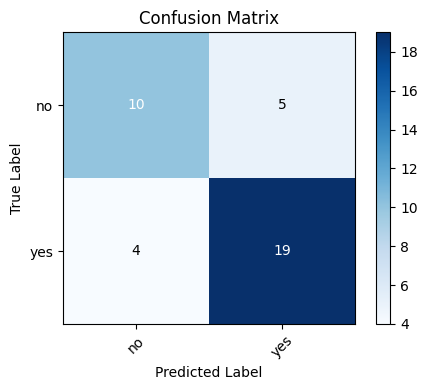

In [ ]:
# Model Evaluation and Metrics
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load best saved model
model.load_state_dict(torch.load("/content/best_brain_tumor_model.pth", map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

#  Classification metrics
print("✅ Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

#  Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)

# ROC-AUC score
try:
    auc_score = roc_auc_score(all_labels, all_probs)
    print(f"\nROC-AUC Score: {auc_score:.4f}")
except Exception as e:
    print("Could not compute ROC-AUC:", e)

# Plot confusion matrix
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()


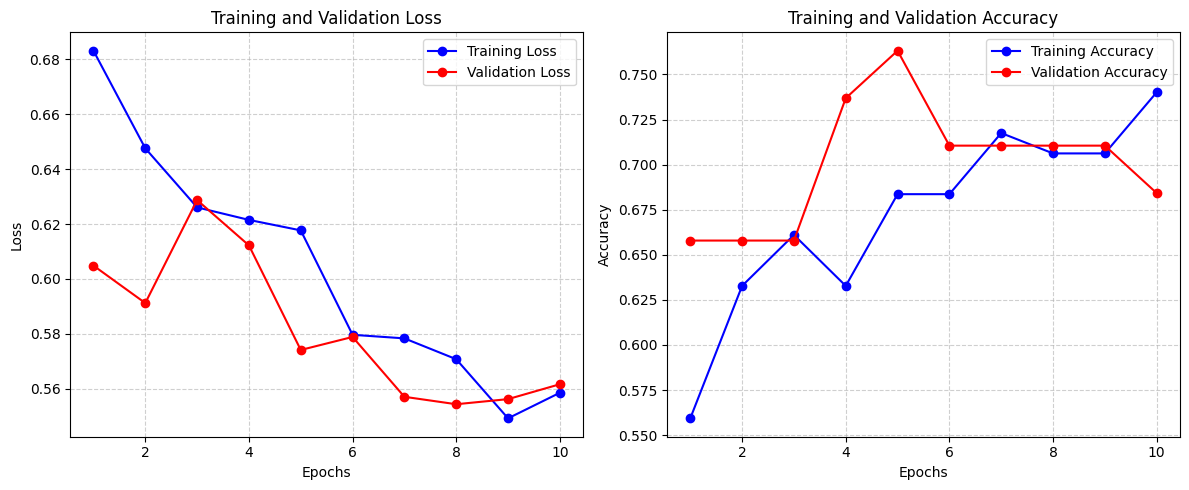

In [ ]:
# Training and Validation Curves
import matplotlib.pyplot as plt


train_losses = [x[0] for x in train_history]
train_accs   = [x[1] for x in train_history]
val_losses   = [x[0] for x in val_history]
val_accs     = [x[1] for x in val_history]

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs, val_losses, 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_accs, 'r-o', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


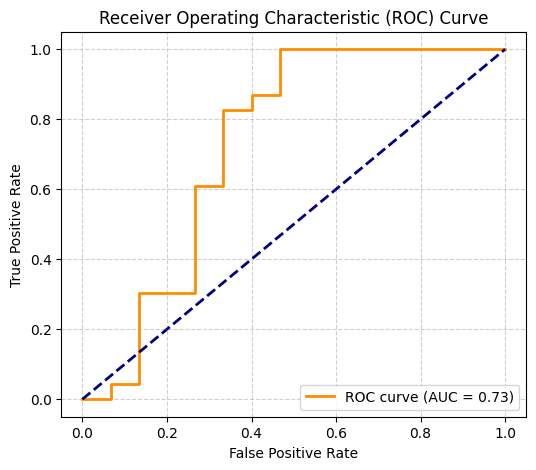

In [ ]:
# ROC Curve Visualization
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


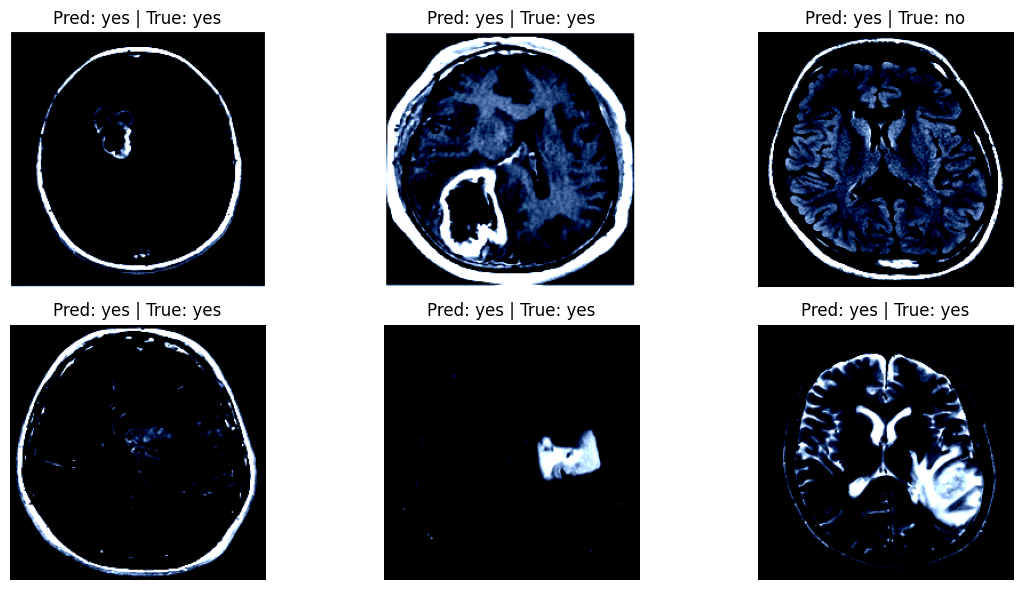

In [ ]:
# Visualize Model Predictions
import random
import torch


samples = random.sample(range(len(test_dataset)), 6)
plt.figure(figsize=(12,6))

for i, idx in enumerate(samples):
    img, label = test_dataset[idx]
    model.eval()
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred_class = pred.argmax(1).item()

    plt.subplot(2, 3, i+1)
    plt.imshow(img.permute(1, 2, 0).cpu().numpy())
    plt.title(f"Pred: {class_names[pred_class]} | True: {class_names[label]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 32.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, 

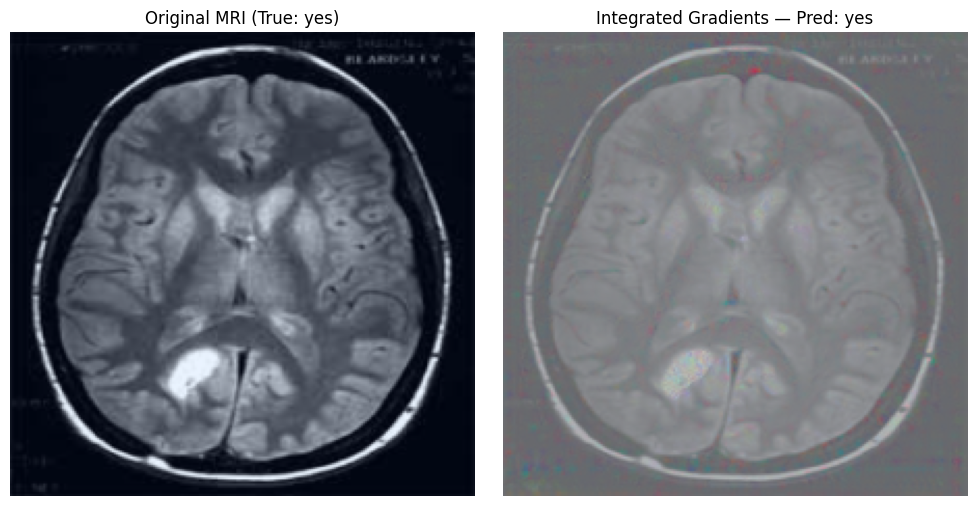

In [ ]:
# Integrated Gradients Visualization
!pip install captum --quiet

import torch
import matplotlib.pyplot as plt
import numpy as np
from captum.attr import IntegratedGradients
from torchvision.transforms.functional import to_pil_image

model.eval()

# Pick one test image
idx = random.randint(0, len(test_dataset) - 1)
img, label = test_dataset[idx]
input_tensor = img.unsqueeze(0).to(device)

# Create Integrated Gradients object
ig = IntegratedGradients(model)


output = model(input_tensor)
pred_class = output.argmax(1).item()
attr, delta = ig.attribute(input_tensor, target=pred_class, return_convergence_delta=True)


attr = attr.squeeze().detach().cpu().numpy().transpose(1, 2, 0)
attr = (attr - attr.min()) / (attr.max() - attr.min())

# Original image
orig = img.permute(1, 2, 0).cpu().numpy()
orig = (orig - orig.min()) / (orig.max() - orig.min())

# Overlay visualization
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(orig)
plt.title(f"Original MRI (True: {class_names[label]})")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(orig, alpha=0.6)
plt.imshow(attr, cmap='inferno', alpha=0.5)
plt.title(f"Integrated Gradients — Pred: {class_names[pred_class]}")
plt.axis('off')

plt.tight_layout()
plt.show()
